<div style="background: linear-gradient(135deg, #0d1b2a 0%, #1b263b 55%, #415a77 100%); padding: 28px 32px; border-radius: 12px; margin-bottom: 24px; font-family: 'Segoe UI', Arial, sans-serif; box-shadow: 0 4px 24px rgba(0,0,0,0.25);">
  <div style="display: flex; align-items: center; gap: 28px; flex-wrap: wrap;">
    <img src="https://www.theochem2.ruhr-uni-bochum.de/tc/mam/images/logo2026.jpg" style="height: 90px; border-radius: 8px; box-shadow: 0 2px 10px rgba(0,0,0,0.4);" alt="Workshop Logo 2026"/>
    <div>
      <h1 style="color: #e0e7ff; margin: 0 0 6px 0; font-size: 1.5em; font-weight: 700; line-height: 1.25;">Machine Learning Potentials:<br/>from interfaces to solution</h1>
      <p style="color: #93c5fd; margin: 0 0 6px 0; font-size: 1.05em; font-weight: 600; letter-spacing: 0.3px;">✦ From potentials to phase diagrams</p>
    </div>
  </div>
</div>


# Computing the Ag–Cu phase diagram from atomistic simulations

The overarching goal of this session is to compute the **Ag–Cu binary phase diagram directly from atomistic simulations** without any experimental inputs, or empirical fits. This is a demanding and beautiful test of modern machine-learning interatomic potentials: remember the potentials have not seen any finite temperature data!

The experimental Ag–Cu phase diagram looks like this:

![Ag–Cu phase diagram](img/Phase-diagram-of-Cu-Ag_W640.jpg)

*Experimental Ag–Cu phase diagram. The system shows a eutectic at ~72 at% Ag and ~1052 K, with very limited mutual solid solubility. Image from [Kawecki et al.](https://doi.org/10.2478/v10172-012-0141-1)*

---

## 1. Melting temperature

---

To reproduce this diagram computationally we need the free energies of the solid and liquid phases as a function of temperature and composition. An point to get started are the melting temperatures of the pure end members, we focus on Cu:

- Pure **Cu**: experimental $T_m \approx 1358$ K, from DFT $T_m = 1251 \pm 15$ [Ref](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.96.224202)


### Why this is computationally demanding

To arrive at the full phase diagram, we need to calculate the free energies at given compositions and temperaturates. For the full Ag–Cu diagram this would require many hours of GPU time.

### What we will actually do today

To get hands-on experience within the time of this tutorial, we will compute the melting temperature of pure Cu as the first end member. We use [**GRACE-1L-OMAT**](https://github.com/ICAMS/grace-tensorpotential), a universal machine-learning potential we saw extensively in this workshop.

We will use [calphy](https://calphy.org) to automate the free energy calculations. The workflow is:

1. Run a temperature-scaling free energy calculation for FCC Cu solid over a temperature range - get $F_\mathrm{solid}(T)$.
2. Run the same for **liquid** Cu over the same range - get $F_\mathrm{liquid}(T)$.
3. Find the temperature where $F_{\text{solid}}(T) = F_{\text{liquid}}(T)$ — that is the melting point.

The input file `input1.yaml` is already prepared and defines both calculations. Since the calculations will take few minutes to run, we will first run them and then come back to see what the input file contains.


### Running the calculations

The calculations are submitted to the cluster's GPU queue via SLURM. Open a terminal and run:

```bash
cd                                                           # go to your home directory
source load_calphy.sh                                        # activate the calphy environment
grace_models list                                            # check if GRACE-1L-OMAT model exists
grace_models download GRACE-1L-OMAT                          # download the model, only needed if you have not downloaded
git clone https://github.com/ICAMS/calphy-tutorial.git       # clone the repository
cd calphy-tutorial                                           # enter the tutorial directory
calphy -i input1.yaml                                        # submit both solid and liquid jobs
```

calphy reads the input file, generates LAMMPS input scripts and SLURM batch scripts for each calculation, and submits them automatically. You can monitor progress with:

```bash
squeue -u $USER
```

The two jobs (solid and liquid) each take roughly **5 minutes** on an A100 GPU. While they run, we will examine the input file to understand what calphy is doing.


### Understanding `input1.yaml`

The file defines two calculations in a YAML list — one for the solid and one for the liquid. Both share the same structure; here is a walk-through of each key:

#### System definition

| Key | Value | Meaning |
|---|---|---|
| `element` | `[Cu]` | Chemical symbol(s) of the species |
| `mass` | `[63.546]` | Atomic mass in g/mol |
| `lattice` | `fcc` / `liquid.data` | Starting structure: `fcc` lets calphy build a perfect crystal; the liquid calculation starts from a pre-melted LAMMPS data file |
| `repeat` | `[4, 4, 4]` | Replicate the unit cell to make a 4×4×4 supercell (256 atoms for FCC Cu). This is intentionally small to keep the tutorial fast — production runs typically use 500–2000 atoms. |

#### Thermodynamic conditions

| Key | Value | Meaning |
|---|---|---|
| `temperature` | `[1200, 1400]` | Temperature range (K) for the temprature sweep. calphy integrates $F(T)$ from 1200 K to 1400 K . |
| `pressure` | `0` | Target pressure in bar (zero pressure here) |
| `mode` | `ts` | Temperature scaling - method that yields $F(T)$ along a path |
| `reference_phase` | `solid` / `liquid` | Which reference free-energy model to use as a starting point for thermodynamic integration (Einstein crystal for solid, Uhlenbeck–Ford for liquid) |

#### Potential

```yaml
pair_style: grace
pair_coeff: '* * /path/to/GRACE-1L-OMAT Cu'
```

This instructs LAMMPS to use the GRACE-1L-OMAT foundation potential via the `grace` pair style. 

#### MD protocol

| Key | Value | Meaning |
|---|---|---|
| `n_equilibration_steps` | `1000` | Steps to equilibrate the system at the starting temperature before integration. Short for speed; production uses ≥ 10 000. |
| `n_switching_steps` | `1000` | Steps over which the Hamiltonian is switched. Intentionally very small here to make the tutorial run in ~5 min; accurate results need ≥ 50 000 steps. |
| `n_iterations` | `1` | Number of independent forward/backward sweeps for error estimation. |

---


Once both jobs finish, the output directories will contain `temperature_sweep.dat` files with the computed free energies at each temperature, and we can call `find_transition_temperature` to locate the crossing point.

<div style="background: linear-gradient(135deg, #e0f7f4 0%, #d0f0e8 100%); border-left: 4px solid #2abf9e; border-radius: 8px; padding: 16px 20px; margin: 16px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong style="color: #1a7a65;">💡 Didn't finish the calculations in time?</strong>
  <p style="margin: 8px 0 8px 0; color: #2d4a44;">You can download precomputed results and continue from here. Run the following in a terminal:</p>
  <pre style="background: #c8ede7; border-radius: 4px; padding: 10px; margin: 8px 0; color: #1a3a34;"><code>wget -O tm.tar.gz https://ruhr-uni-bochum.sciebo.de/s/Ymzceq8d7CmJGZ3/download
tar -xvf tm.tar.gz</code></pre>
  <p style="margin: 8px 0 0 0; color: #2d4a44;">Or run directly in a notebook cell by prefixing each command with <code>!</code>. Once extracted, update the folder paths in the cells below accordingly.</p>
</div>


In [1]:
from calphy.postprocessing import find_transition_temperature

np.float64(1264.0)

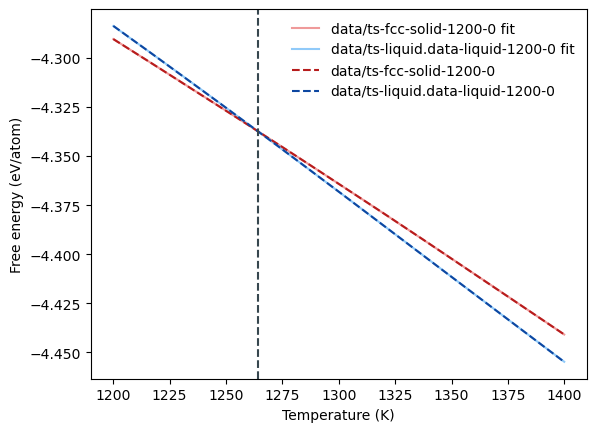

In [3]:
find_transition_temperature('data/ts-fcc-solid-1200-0', 
'data/ts-liquid.data-liquid-1200-0',)

The calculated melting temperature is in excellent agreement with the DFT results, given that we used only 256 atoms and 1000 switching steps (a very short calculation)!

---

## 2. Free energy as a function of composition

---

We learned how to calculate the free energy with temperature. To get full phase diagrams, we also need to calculate free energy with composition, which is what we will look at in this section.

### Alchemical / composition scaling

We find $\Delta F$ along a composition path using thermodynamic integration over a fictitious alchemical pathway: we gradually transform Cu atoms into Ag atoms. In calphy this is called `mode: composition_scaling` (composition scaling).

How it is done:

1. Start from a well-equilibrated simulation box at a fixed reference composition (e.g. pure Cu, $x_\text{Ag}=0$).
2. Switch $\lambda$ from 0 to 1, where $\lambda$ interpolates the interatomic potential between the two endpoint compositions. At $\lambda=1$ the box looks like an $x_\text{Ag}=0.1$ alloy.

Repeating this at successive composition steps builds up $F(x)$ across the full range, starting from the known absolute free energy of the pure element computed in Section 1.


- We use alchemical sampling,
- start from pure system/or any - change composition
- thermodynamic integration between the two composutions
- get free energy difference in chaging composition

Once again, the input file has been provided. You can submit the calculations to the queue by:

```
calphy -i input2.yaml
```

While it is running we can take a look at how the input file looks like. 

After the calculations are over, we can read in the results and plot it.

<div style="background: linear-gradient(135deg, #e0f7f4 0%, #d0f0e8 100%); border-left: 4px solid #2abf9e; border-radius: 8px; padding: 16px 20px; margin: 16px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong style="color: #1a7a65;">💡 Didn't finish the calculations in time?</strong>
  <p style="margin: 8px 0 8px 0; color: #2d4a44;">You can download precomputed results and continue from here. Run the following in a terminal:</p>
  <pre style="background: #c8ede7; border-radius: 4px; padding: 10px; margin: 8px 0; color: #1a3a34;"><code>wget -O fex.tar.gz https://ruhr-uni-bochum.sciebo.de/s/QK3EwFsmXtWFiG7/download
tar -xvf fex.tar.gz</code></pre>
  <p style="margin: 8px 0 0 0; color: #2d4a44;">Or run directly in a notebook cell by prefixing each command with <code>!</code>. Once extracted, update the folder paths in the cells below accordingly.</p>
</div>


In [32]:
from calphy.postprocessing import read_report
import matplotlib.pyplot as plt

In [ ]:
c10 = read_report('x10-composition_scaling-solid.data--800-0')['results']
c20 = read_report('x20-composition_scaling-solid.data--800-0')['results']

In [34]:
c10

{'com_correction': 0.0,
 'einstein_crystal': 0.0,
 'entropy_contribution': -2.8013483195631826e-05,
 'error': 0.0,
 'free_energy': -0.06581721331815266,
 'mass_correction': -0.005471774342516117,
 'pv': 0.0,
 'reference_system': 0.0,
 'unit': 'eV/atom',
 'work': -0.07128898766066877}

In [35]:
x = [0, 0.1, 0.2]
fe = [0, c10['free_energy'], c20['free_energy']]

Text(0, 0.5, '$\\Delta F$ (eV/atom)')

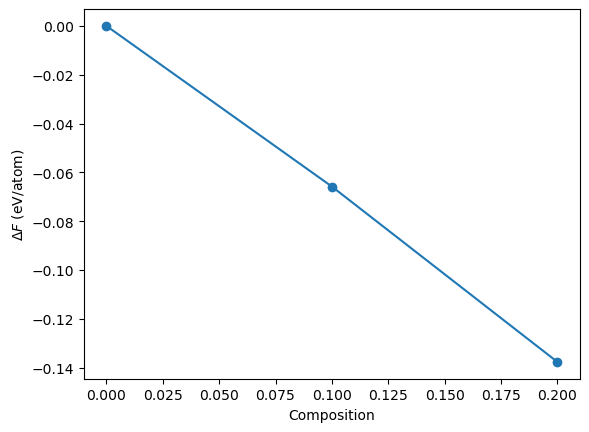

In [37]:
plt.plot(x, fe, 'o-')
plt.xlabel('Composition')
plt.ylabel(r'$\Delta F$ (eV/atom)')

The plot shows the free energy change of the FCC solid at 800 K as a function of Ag content. Each point is the cumulative $\Delta F$ obtained by integrating the alchemical path from pure Cu.

We have now discussed the two main ingredients we need to go to the full phase diagram!

---

## 3. Complete Ag–Cu phase diagram

---

With the melting temperature of pure Cu established, we now move on to the full binary system. Computing a complete phase diagram requires free energy calculations across the entire composition range $x_\text{Ag} \in [0, 1]$, at every temperature of interest, for each of the three phases present in Ag–Cu:

- **`cufcc`** — Cu-rich FCC solid
- **`agfcc`** — Ag-rich FCC solid
- **`lqd`** — liquid

In practice this amounts to hundreds of individual calphy runs (although each takes only about 12 mins!), well beyond what can be executed during a tutorial. We therefore work with a set of precomputed results generated with GRACE-1L-OMAT using a 500-atom supercell and a larger number of switching steps for better numerical accuracy.

Once the free energies are available, calphy’s `PhaseDiagram` class handles all the thermodynamics:

1. Convert absolute free energies into free energies of mixing $\Delta F_\text{mix}(x, T)$ relative to the pure-element references.
2. At each temperature, perform common tangent constructions on the competing phase curves to identify two-phase coexistence regions.
3. Trace those boundaries across temperatures to obtain the full phase diagram.


### Precomputed dataset

The archive contains calphy output directories organised by phase and composition:

| Folder | Phase | Composition range |
|---|---|---|
| `AgCu_data/cufcc` | Cu-rich FCC solid | $x_\text{Ag} = 0.0 \ldots 0.3$ |
| `AgCu_data/agfcc` | Ag-rich FCC solid | $x_\text{Ag} = 0.7 \ldots 1.0$ |
| `AgCu_data/lqd`   | Liquid            | $x_\text{Ag} = 0.0 \ldots 1.0$ |

Each subfolder is the output of a direct free energy and composition scaling calphy runs. Download the archive with the cell below.

Run the cell below to download the archive:

In [8]:
! wget -O AgCu.tar.gz https://ruhr-uni-bochum.sciebo.de/s/KQze4NRJxgjwnDW/download

--2026-03-04 20:41:24--  https://ruhr-uni-bochum.sciebo.de/s/KQze4NRJxgjwnDW/download
Resolving ruhr-uni-bochum.sciebo.de (ruhr-uni-bochum.sciebo.de)... 128.176.1.2
Connecting to ruhr-uni-bochum.sciebo.de (ruhr-uni-bochum.sciebo.de)|128.176.1.2|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://ruhr-uni-bochum.sciebo.de/public.php/dav/files/KQze4NRJxgjwnDW/?accept=zip [following]
--2026-03-04 20:41:25--  https://ruhr-uni-bochum.sciebo.de/public.php/dav/files/KQze4NRJxgjwnDW/?accept=zip
Reusing existing connection to ruhr-uni-bochum.sciebo.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 192605135 (184M) [application/gzip]
Saving to: ‘AgCu.tar.gz’

AgCu.tar.gz         100%[===================>] 183.68M  9.95MB/s    in 18s     

2026-03-04 20:41:42 (10.4 MB/s) - ‘AgCu.tar.gz’ saved [192605135/192605135]



Then extract the archive to create the `AgCu_data/` directory with all three phase folders:

In [9]:
! tar -xvf AgCu.tar.gz

x AgCu_data/
x AgCu_data/lqd/
x AgCu_data/lqd/lqd-0.10-fe-lqd.lammps.datalqd-0.10.comp.mod-liquid-200-0.err
x AgCu_data/lqd/lqd-0.80-fe-lqd.lammps.datalqd-0.80.comp.mod-liquid-1100-0.out
x AgCu_data/lqd/lqd-0.00-fe-lqd.lammps.datalqd-0.00.comp.mod-liquid-200-0/
x AgCu_data/lqd/lqd-0.00-fe-lqd.lammps.datalqd-0.00.comp.mod-liquid-200-0/calphy.log
x AgCu_data/lqd/lqd-0.00-fe-lqd.lammps.datalqd-0.00.comp.mod-liquid-200-0/input_file.yaml
x AgCu_data/lqd/lqd-0.00-fe-lqd.lammps.datalqd-0.00.comp.mod-liquid-200-0/traj.melt
x AgCu_data/lqd/lqd-0.00-fe-lqd.lammps.datalqd-0.00.comp.mod-liquid-200-0/melting.log.lammps
x AgCu_data/lqd/lqd-0.80-fe-lqd.lammps.datalqd-0.80.comp.mod-liquid-600-0.out
x AgCu_data/lqd/lqd-0.20-fe-lqd.lammps.datalqd-0.20.comp.mod-liquid-400-0.out
x AgCu_data/lqd/lqd-0.70-fe-lqd.lammps.datalqd-0.70.comp.mod-liquid-900-0.out
x AgCu_data/lqd/lqd-1.00-fe-lqd.lammps.datamod.data-liquid-1100-0.out
x AgCu_data/lqd/lqd-0.00-fe-lqd.lammps.datalqd-0.00.comp.mod-liquid-700-0/
x AgCu_

### Computing and plotting the phase diagram

With the data unpacked, we load the `PhaseDiagram` class and point it at the three phase folders. Setting `reference_element='Ag'` places $x_\text{Ag}$ on the composition axis.

`calculate()` does all the thermodynamic work in one call: it reads the free energy data for every composition and temperature, constructs the mixing free energy curves $\Delta F_\text{mix}(x)$ for each phase, and performs common tangent constructions across the full temperature range 400–1400 K in 5 K steps. 

Finally, `plot()` renders the computed phase boundaries.

In [11]:
from calphy.phase_diagram import PhaseDiagram

In [12]:
pd = PhaseDiagram(
    folders={'cufcc': 'AgCu_data/cufcc', 'agfcc': 'AgCu_data/agfcc', 'lqd': 'AgCu_data/lqd'},
    reference_element='Ag',
)

In [ ]:
pd.calculate(T_range=(400, 1400), T_step=5,
             #method='redlich-kister', 
             remove_self_tangents_for=['lqd', 'agfcc', 'cufcc'])

Text(36.722222222222214, 0.5, 'T (K)')

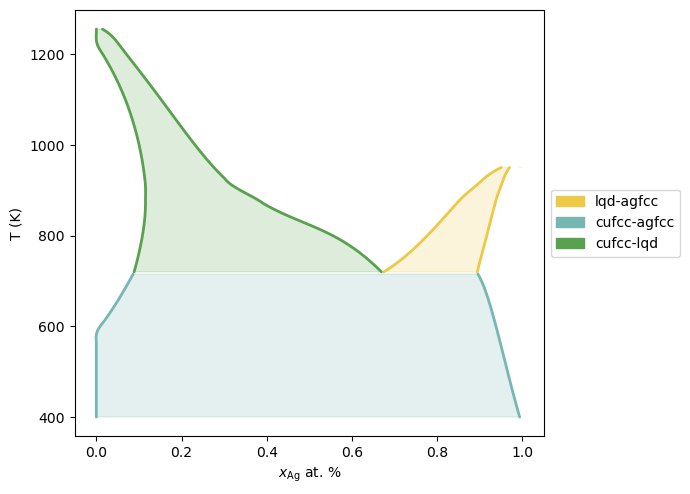

In [14]:
fig, ax = pd.plot()
ax.set_xlabel(r'$x_\mathrm{Ag}$ at. %')
ax.set_ylabel(r'T (K)')

The computed diagram closely reproduces the experimental phase diagram: a eutectic at Ag rich region, negligible mutual solid solubility, and end-member melting points in good agreement with DFT. This is a fully atomistic result: no experimental thermodynamic data was used anywhere in the calculation.

### A closer look at the free energies

To understand the driving forces behind the phase boundaries, it is instructive to examine the free energy curves at a specific temperature. At 720 K the system is close to the eutectic point, which makes it a good temperature to see the common tangent construction in action.

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'T = 720 K'}, xlabel='Composition', ylabel='F (eV/atom)'>)

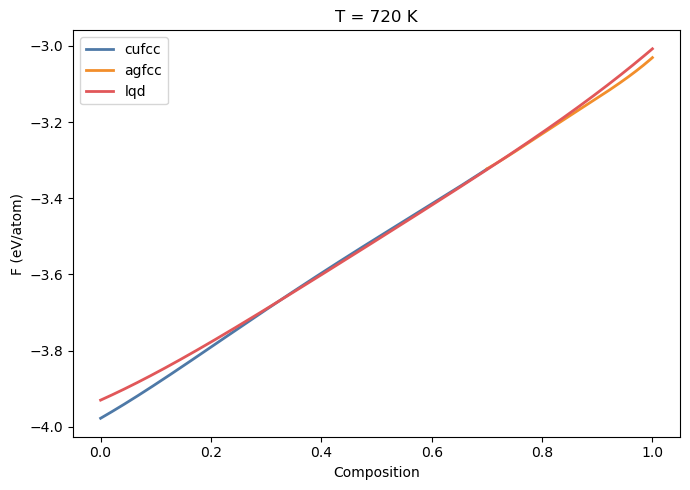

In [29]:
pd.plot_free_energy(T=720)

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'T = 720 K'}, xlabel='Composition', ylabel='$\\Delta F_\\mathrm{mix}$ (eV/atom)'>)

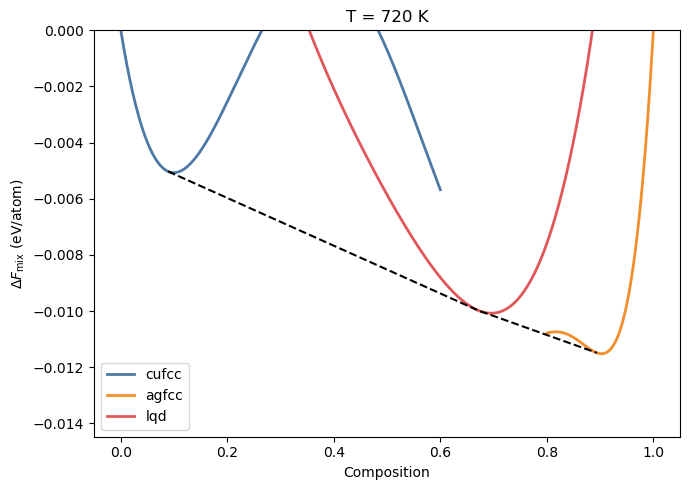

In [28]:
pd.plot_free_energy_mixing(T=720)

<hr style="border: none; border-top: 1px solid #415a77; margin: 32px 0 24px 0;"/>
<div style="background: linear-gradient(135deg, #0d1b2a 0%, #1b263b 55%, #415a77 100%); padding: 24px 32px; border-radius: 12px; font-family: 'Segoe UI', Arial, sans-serif; box-shadow: 0 4px 24px rgba(0,0,0,0.25);">
  <h3 style="color: #e0e7ff; margin: 0 0 16px 0; font-size: 1.1em; font-weight: 700;">📚 Further Reading</h3>
  <ul style="color: #cbd5e1; margin: 0 0 20px 0; padding-left: 20px; line-height: 1.9; font-size: 0.91em;">
    <li>Menon et al. <em>Automated Free-Energy Calculation from Atomistic Simulations.</em> <strong>Phys. Rev. Materials</strong> 5, 103801 (2021). <a href="https://doi.org/10.1103/PhysRevMaterials.5.103801" style="color: #93c5fd;">doi:10.1103/PhysRevMaterials.5.103801</a></li>
    <li>Menon et al. <em>From electrons to phase diagrams with machine learning potentials using pyiron based automated workflows.</em> <strong>npj Comput Mater</strong> 10, 261 (2024). <a href="https://doi.org/10.1038/s41524-024-01441-0" style="color: #93c5fd;">doi:10.1038/s41524-024-01441-0</a></li>
    <li>Lysogorskiy et al. <em>Performant implementation of the atomic cluster expansion (PACE) and application to copper and silicon.</em> <strong>npj Comput Mater</strong> 7, 97 (2021). <a href="https://doi.org/10.1038/s41524-021-00559-9" style="color: #93c5fd;">doi:10.1038/s41524-021-00559-9</a></li>
    <li>Bochkarev et al. <em>Efficient parametrization of the atomic cluster expansion.</em> <strong>Phys. Rev. Materials</strong> 6, 013804 (2022). <a href="https://doi.org/10.1103/PhysRevMaterials.6.013804" style="color: #93c5fd;">doi:10.1103/PhysRevMaterials.6.013804</a></li>
    <li>Lysogorskiy et al. <em>Active learning strategies for atomic cluster expansion models.</em> <strong>Phys. Rev. Materials</strong> 7, 043801 (2023). <a href="https://doi.org/10.1103/PhysRevMaterials.7.043801" style="color: #93c5fd;">doi:10.1103/PhysRevMaterials.7.043801</a></li>
    <li>Bochkarev et al. <em>Graph Atomic Cluster Expansion for Semilocal Interactions beyond Equivariant Message Passing.</em> <strong>Phys. Rev. X</strong> 14, 021036 (2024). <a href="https://doi.org/10.1103/PhysRevX.14.021036" style="color: #93c5fd;">doi:10.1103/PhysRevX.14.021036</a></li>
    <li>Lysogorskiy et al. <em>Graph atomic cluster expansion for foundational machine learning interatomic potentials.</em> <strong>npj Comput Mater</strong> (2026). <a href="https://doi.org/10.1038/s41524-026-01979-1" style="color: #93c5fd;">doi:10.1038/s41524-026-01979-1</a></li>
  </ul>
  <hr style="border: none; border-top: 1px solid #415a77; margin: 4px 0 16px 0;"/>
  <div style="display: flex; gap: 16px; align-items: center; flex-wrap: wrap;">
    <span style="color: #93c5fd; font-weight: 600; font-size: 0.93em; margin-right: 4px;">Software:</span>
    <a href="https://github.com/ICAMS/calphy" target="_blank" rel="noopener" style="display: inline-flex; align-items: center; gap: 7px; color: #e0e7ff; text-decoration: none; font-size: 0.91em; background: rgba(255,255,255,0.07); padding: 7px 16px; border-radius: 7px; border: 1px solid #415a77;">
      <svg height="17" viewBox="0 0 16 16" width="17" aria-hidden="true" style="fill: #e0e7ff; flex-shrink: 0;"><path d="M8 0C3.58 0 0 3.58 0 8c0 3.54 2.29 6.53 5.47 7.59.4.07.55-.17.55-.38 0-.19-.01-.82-.01-1.49-2.01.37-2.53-.49-2.69-.94-.09-.23-.48-.94-.82-1.13-.28-.15-.68-.52-.01-.53.63-.01 1.08.58 1.23.82.72 1.21 1.87.87 2.33.66.07-.52.28-.87.51-1.07-1.78-.2-3.64-.89-3.64-3.95 0-.87.31-1.59.82-2.15-.08-.2-.36-1.02.08-2.12 0 0 .67-.21 2.2.82.64-.18 1.32-.27 2-.27.68 0 1.36.09 2 .27 1.53-1.04 2.2-.82 2.2-.82.44 1.1.16 1.92.08 2.12.51.56.82 1.27.82 2.15 0 3.07-1.87 3.75-3.65 3.95.29.25.54.73.54 1.48 0 1.07-.01 1.93-.01 2.2 0 .21.15.46.55.38A8.013 8.013 0 0016 8c0-4.42-3.58-8-8-8z"/></svg>
      calphy
    </a>
    <a href="https://calphy.org/en/latest/" target="_blank" rel="noopener" style="display: inline-flex; align-items: center; gap: 7px; color: #e0e7ff; text-decoration: none; font-size: 0.91em; background: rgba(255,255,255,0.07); padding: 7px 16px; border-radius: 7px; border: 1px solid #415a77;">
      <svg height="17" viewBox="0 0 24 24" width="17" aria-hidden="true" style="fill: #e0e7ff; flex-shrink: 0;"><path d="M14 2H6a2 2 0 0 0-2 2v16a2 2 0 0 0 2 2h12a2 2 0 0 0 2-2V8l-6-6zm-1 1.5L18.5 9H13V3.5zM6 20V4h5v7h7v9H6z"/></svg>
      Documentation
    </a>
  </div>
</div>


## Theory

![](img/fig1.png)

- free energy of reference system are known: Einstein crystal, [Uhlenbeck-Ford model](https://doi.org/10.1063/1.4967775)
- the two systems are coupled by 
$$
H(\lambda) = \lambda H_f + (1-\lambda)\lambda H_i
$$
- Run calculations for each $\lambda$ and integrate 
$$
G_f = G_i + \int_{\lambda=0}^1 d\lambda \bigg \langle  \frac{\partial H(\lambda)}{\partial \lambda } \bigg \rangle
$$

To calculate $F$,

- for each phase
    - for each pressure
        - for each temperature
            - for each $\lambda$

If we choose 100 different $\lambda$ values; 100 calculations are needed for each temperature and pressure! 

**Dimensionality: (phase, $P$, $T$, $\lambda$)**

### Speeding up with non-equilibrium calculations

![](img/cimg5.png)

In this method:

- Discrete $\lambda$ parameter is replaced by a time dependent $\lambda(t)$
- Instead of running calculations at each $\lambda$, run a single, short, non-equilibrium calculation

$$
G_f = G_i + \int_{t_i}^{t_f} dt \frac{d\lambda (t)}{dt}  \frac{ H(\lambda)}{\partial \lambda }
$$

As discussed:
- the coupling parameter $\lambda$ earlier is replaced by a time dependent parameter
- The equation also no longer has an ensemble average  

These aspects makes it quite easy and fast to estimate this integral.

However:
- this equation holds when the switching betwen the system of interest and reference system is carried out infinitely slowly
- Practically, this is not not possible. 

Therefore we can write:

$$
\Delta G = W_{rev} = W_s - E_d
$$

$$
W_s = \int_{t_i}^{t_f} dt \frac{d\lambda (t)}{dt}  \frac{ H(\lambda)}{\partial \lambda }
$$

- $E_d$ is the energy dissipation
- $E_d \to 0$ when $t_f-t_i \to \infty$

So far, so good, but how is this useful?

- Instead of a single transformation from system of interest to reference, we switch back too
- These are called forward $(i \to f)$ and backward $(f \to i)$ switching
- $t_f - t_i = t_{sw}$ is the switching time in each direction
- If $t_{sw}$ is long enough, $E_d^{i \to f} = E_d^{f \to i}$
- and $\Delta G = \frac{1}{2} (W_s^{i \to f} - W_s^{f \to i})$

Now, we have all the components required for actual calculations.

We have also managed to successfully reduce the dimensionality

- for each phase
    - for each pressure
        - for each temperature
            - ~~for each $\lambda$~~

**Dimensionality: (phase, $P$, $T$)**


So, how do we calculate the free energy of a system modelled with a given interatomic potential?

### Free energy of solids

In case of solids, a good choice of a reference system is the Einstein crystal. An Einstein crystal is a set of independent harmonic oscillators attached to the lattice positions. 

The free energy of the Einstein crystal is:

$$
F_E = 3 k_B T \sum_{i} ln \bigg ( \frac{\hbar \omega_i}{k_B T} \bigg )
$$

We need to calculate:

- $\omega$
- A common way is $$  \frac{1}{2} k_i \langle (\Delta \pmb{r}_i)^2 \rangle = \frac{3}{2} k_\mathrm{B} T $$
- $\langle (\Delta \pmb{r}_i)^2 \rangle$ is the mean squared displacement.

### Free energy of liquids

**How is the liquid prepared in this calculation?**

- Start from the given structure
- This structure is heated until it melts.
- Melting of the structure is automatically detected by calphy
- Once melted, it is equilibrated to the required temperature and pressure.

**What about the reference system for liquid?**

The reference system for the Liquid structure is also different. In this case, the Uhlenbeck-Ford system is used as the reference system for liquid.

The Uhlenbeck-Ford model is described by,

$$
E = - \epsilon \log(1-\exp(-r^2/\sigma^2))
$$

where,

$$
\epsilon = p k_B T
$$

$\epsilon$ and $\sigma$ are energy and length scales, respectively.

It is purely repulsive liquid model which does not undergo any phase transformations.

### Free energy with temperature

![](img/cimg6.png)

Gibb's free energy via reversible scaling at a constant pressure is given by,

$ G(N,P,T_f) = G(N,P,T_i) + \dfrac{3}{3}Nk_BT_f\ln{\dfrac{T_f}{T_i}} + \dfrac{T_f}{T_i}\Delta G $,

Therefore, $G(N,P,T_f)$ can be computed from $G(N,P,T_i)$ via the free energy difference $\Delta G$. 

Here, $\Delta G = \dfrac{1}{2}[W_{if}-W_{fi}$] --- (2)

The reversible work is related to the internal energy $U$ by,
$W = \int_{1}^{\lambda_f}<U> \,d\lambda$ --- (3)

Using MD $W$ can be computed as:
- equilibrate for time $t_{eq}$ in NPT ensemble
- switch $\lambda$ : $1->\dfrac{T_f}{T_i}$ over time $t_{sw}$
- calculate work $W_{if}$ from (3)
- equilibrate for time $t_{eq}$ in NPT ensemble
- switch $\lambda$ : $\dfrac{T_f}{T_i}->1$ over time $t_{sw}$
- calculate work $W_{fi}$ from (3).

